Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [51]:
titanic_df = pd.read_csv('train.csv')

print("Інформація про датасет:")
titanic_df.info()

print("\nПерші 5 рядків датафрейму:")
display(titanic_df.head())

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Перші 5 рядків датафрейму:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

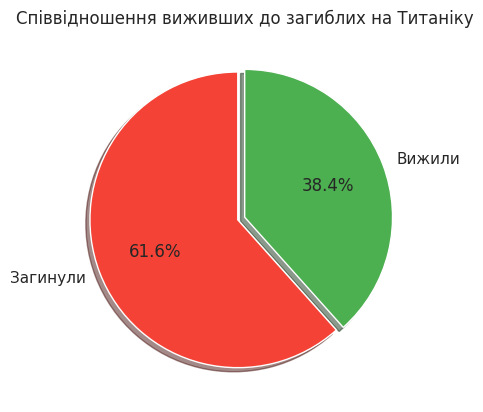

In [52]:
survived_counts = titanic_df['Survived'].value_counts()

plt.pie(survived_counts,
        labels=['Загинули', 'Вижили'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#F44336', '#4CAF50'],
        explode=(0.05, 0),
        shadow=True)
plt.title('Співвідношення виживших до загиблих на Титаніку')

plt.show()

На побудованій круговій діаграмі проілюстровано загальне співвідношення пасажирів Титаніка за статусом виживання. Більшість пасажирів з даної вибірки, а саме близько 61.6% загинули. Врятуватися вдалося меншості, а саме 38.4% пасажирів.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


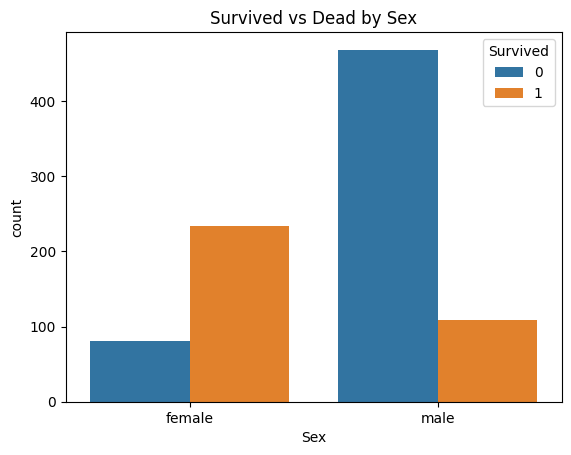

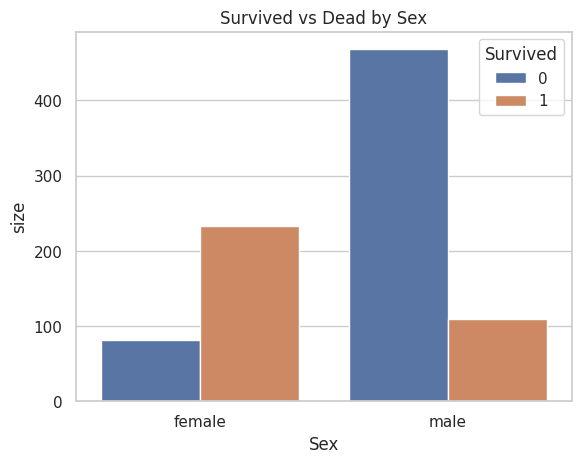

In [58]:
grouped_df = titanic_df.groupby(['Sex', 'Survived'], as_index=False).size()

sns.barplot(data=grouped_df, x='Sex', y='size', hue='Survived')

plt.title('Survived vs Dead by Sex')
plt.show()

Побудована діаграма показує залежність шансів на виживання від статі пасажира.
Серед чоловіків кількість загиблих значно перевищує кількість тих, хто вижив. Чоловіки складали більшість пасажирів, але їхній рівень виживаності є найнижчим.

Серед жінок ситуація кардинально інша, бо кількість врятованих дуже перевищує кількість загиблих.

Отже, стать була одним із ключових факторів виживання під час катастрофи Титаніка. Це можна пояснити тим, що жінок і дітей евакуювали в першу чергу.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

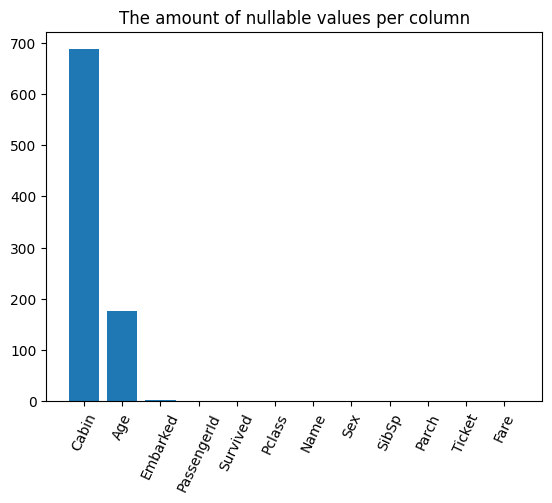

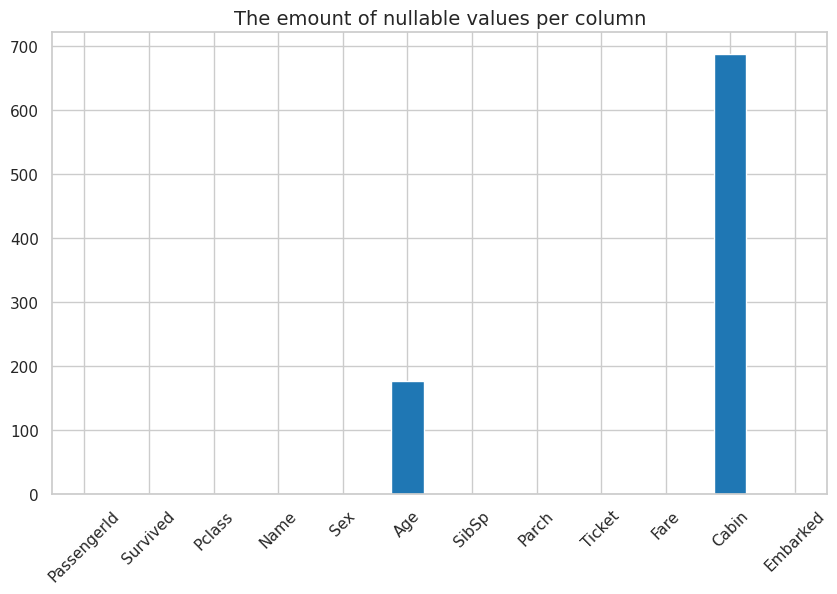

In [54]:
import matplotlib.pyplot as plt

missing_values = titanic_df.isnull().sum()

plt.figure(figsize=(10, 6))

missing_values.plot(kind='bar', color='#1f77b4')

plt.title('The emount of nullable values per column', fontsize=14)

plt.xticks(rotation=45)

plt.show()

Побудована горизонтальна діаграма демонструє наявність та кількість пропущених значень у кожній з колонок датасету. З графіка чітко видно, що більшість ознак є повними, однак дві колонки містять пропуски:

Каюта: Має найбільшу кількість пропусків(майже 700). Оскільки даних бракує для більшості пасажирів, цю колонку може бути доцільно вилучити з подальшого аналізу.

Вік: Містить значну кількість пропусків (близько 200). Оскільки вік є важливою характеристикою, ці пропуски можна заповнити медіанним значенням.

Візуалізація дозволила виявити проблемні місця в даних.

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

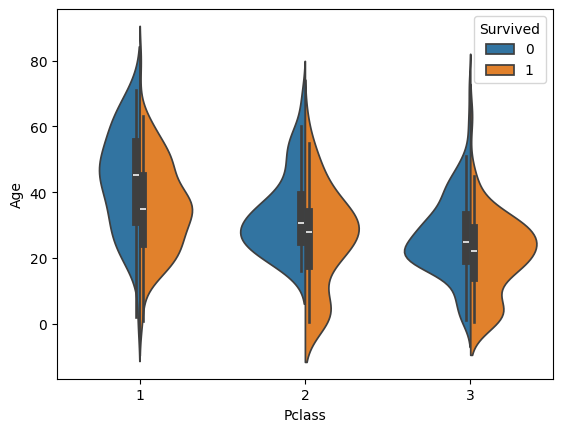

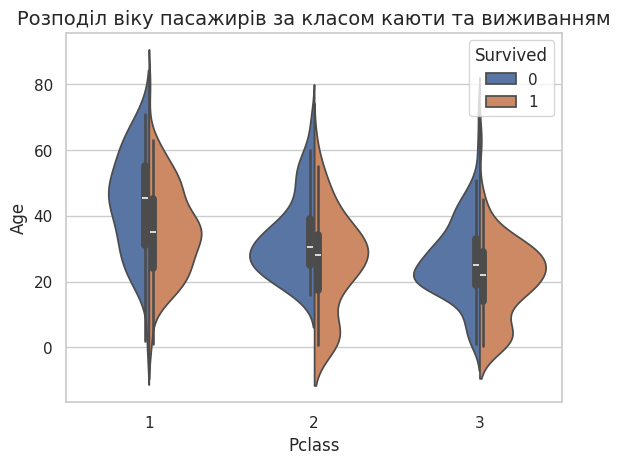

In [55]:
sns.violinplot(data=titanic_df, x='Pclass', y='Age', hue='Survived', split=True)

plt.title('Розподіл віку пасажирів за класом каюти та виживанням', fontsize=14)

plt.show()

Побудована скрипкова діаграма ілюструє розподіл віку пасажирів залежно від їхнього класу та статусу виживання.

Віковий розподіл за класами: Пасажири 1-го класу в середньому були старшими за пасажирів 2-го та 3-го класів (потовщення графіків для 1-го класу знаходиться вище по осі Y). Наймолодша аудиторія подорожувала 3-м класом.

Шанси на виживання серед дітей: У 2-му та 3-му класах на помаранчевій стороні чітко видно потовщення в нижній частині графіка. Це означає, що маленькі діти в цих класах мали значно вищий шанс на порятунок порівняно з дорослими.

Дорослі у 3-му класі: Синя частина графіка (загиблі) для 3-го класу має сильне розширення у діапазоні 20-30 років. Це свідчить про те, що саме молоді дорослі з 3-го класу склали найбільшу частку загиблих у цій катастрофі.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


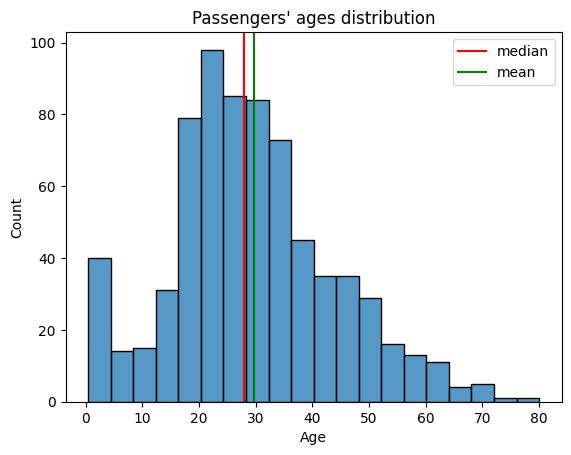

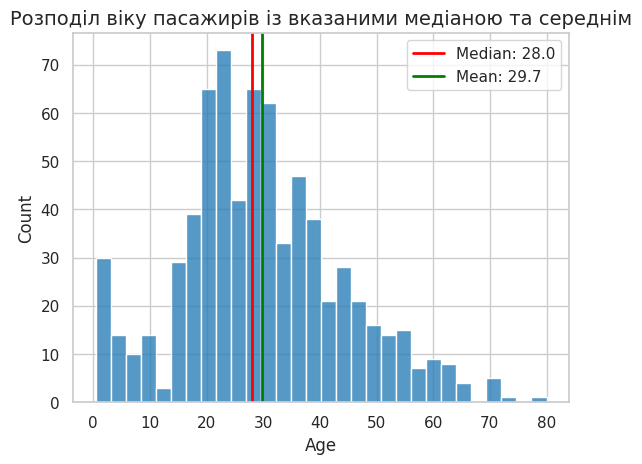

In [56]:
sns.histplot(titanic_df['Age'].dropna(), bins=30, color='#1f77b4', kde=False)

median_val = titanic_df['Age'].median()
mean_val = titanic_df['Age'].mean()

plt.axvline(median_val, color='red', linestyle='-', linewidth=2,
            label=f'Median: {median_val:.1f}')

plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Mean: {mean_val:.1f}')

plt.title('Розподіл віку пасажирів із вказаними медіаною та середнім', fontsize=14)
plt.legend()

plt.show()

Побудована гістограма демонструє частотний розподіл віку пасажирів Титаніка.
Медіана показує значення, яке ділить вибірку рівно навпіл. Близько половини пасажирів були молодшими за 28 років, а інша половина — старшими.

Середнє арифметичне становить близько 29.7 років і знаходиться трохи правіше від медіани.

Це означає, що хоча більшість пасажирів були відносно молодими (від 20 до 30 років), на борту також була присутня певна кількість пасажирів похилого віку (60-80 років), які тягнуть середнє значення вгору.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Чи є різниця у шансах на виживання між пасажирами, які подорожували самі, та тими, хто подорожував із сім'єю?

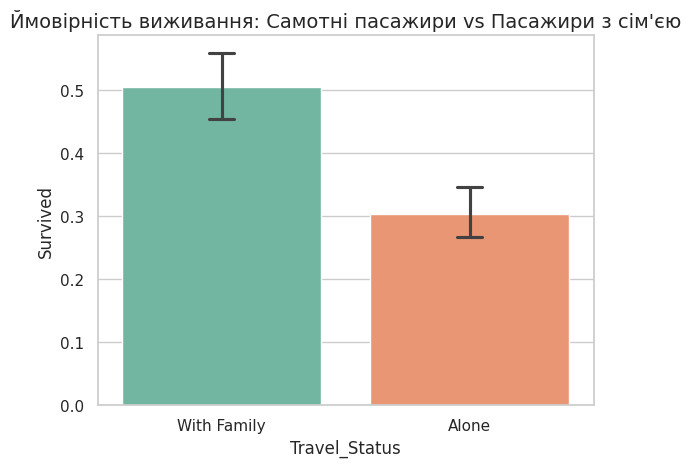

In [57]:
titanic_df['Family_Size'] = titanic_df['SibSp'] + titanic_df['Parch']

titanic_df['Travel_Status'] = titanic_df['Family_Size'].apply(
    lambda x: 'Alone' if x == 0 else 'With Family'
)

sns.barplot(
    x='Travel_Status',
    y='Survived',
    data=titanic_df,
    hue='Travel_Status',
    palette='Set2',
    capsize=0.1,
    legend=False
)

plt.title('Ймовірність виживання: Самотні пасажири vs Пасажири з сім\'єю', fontsize=14)

plt.show()

Для відповіді на це питання було створено нову категорію пасажирів самотні та з сім'єю на основі колонок кількості родичів. Побудована стовпчикова діаграма показує середню ймовірність виживання для кожної групи.

Пасажири, які подорожували з сім'єю, мали значно вищі шанси на виживання (понад 50%).

Натомість пасажири, які подорожували самостійно, мали набагато нижчу ймовірність врятуватися (близько 30%).

Наявність родичів на борту позитивно вплинула на виживання. Це можна пояснити тим, що сім'ї, ймовірно, трималися разом. Жінки та діти, які частіше подорожували в складі сімей, мали пріоритет при посадці у шлюпки, що також піднімає загальний відсоток виживання.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

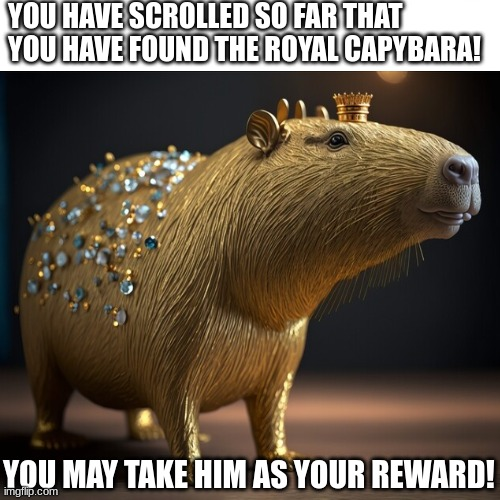